In [28]:
import warnings
warnings.filterwarnings('ignore')  # suppress sklearn version deprecation noise for a clean report

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_auc_score)

from imblearn.over_sampling import SMOTE
# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

# For reproducibility
RANDOM_STATE = 42

In [29]:
df = pd.read_csv('framingham.csv')

print("Shape of dataset (rows, columns):", df.shape)
print("\nColumn dtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
df.head()

Shape of dataset (rows, columns): (4238, 16)

Column dtypes:
 male                 int64
age                  int64
education          float64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object

Missing values:
 male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [30]:
# Statistical summary of numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
male,4238.0,0.429212,0.495022,0.00,0.00,0.0,1.000,1.0
age,4238.0,49.584946,8.572160,32.00,42.00,49.0,56.000,70.0
education,4133.0,1.978950,1.019791,1.00,1.00,2.0,3.000,4.0
currentSmoker,4238.0,0.494101,0.500024,0.00,0.00,0.0,1.000,1.0
cigsPerDay,4209.0,9.003089,11.920094,0.00,0.00,0.0,20.000,70.0
BPMeds,4185.0,0.029630,0.169584,0.00,0.00,0.0,0.000,1.0
prevalentStroke,4238.0,0.005899,0.076587,0.00,0.00,0.0,0.000,1.0
prevalentHyp,4238.0,0.310524,0.462763,0.00,0.00,0.0,1.000,1.0
diabetes,4238.0,0.025720,0.158316,0.00,0.00,0.0,0.000,1.0
totChol,4188.0,236.721585,44.590334,107.00,206.00,234.0,263.000,696.0


In [31]:
TARGET = 'TenYearCHD'

# Check target class distribution (needed later to detect imbalance)
print(df[TARGET].value_counts())
print("\nClass proportion (%):")
print(df[TARGET].value_counts(normalize=True) * 100)

TenYearCHD
0    3594
1     644
Name: count, dtype: int64

Class proportion (%):
TenYearCHD
0    84.804153
1    15.195847
Name: proportion, dtype: float64


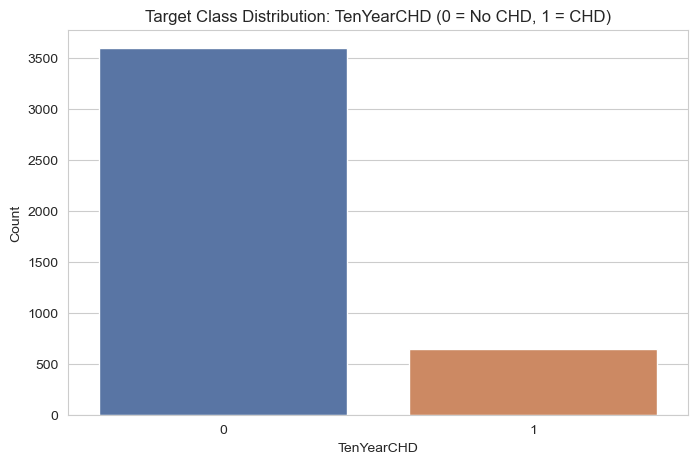

In [32]:
# Visualize target class distribution
plt.figure()
sns.countplot(x=TARGET, data=df, palette=['#4C72B0', '#DD8452'])
plt.title('Target Class Distribution: TenYearCHD (0 = No CHD, 1 = CHD)')
plt.xlabel('TenYearCHD')
plt.ylabel('Count')
plt.show()

In [33]:
# Count missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_summary = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_summary = missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
missing_summary

,Missing Count,Missing %
glucose,388,9.155262
education,105,2.477584
BPMeds,53,1.250590
totChol,50,1.179802
cigsPerDay,29,0.684285
BMI,19,0.448325
heartRate,1,0.023596


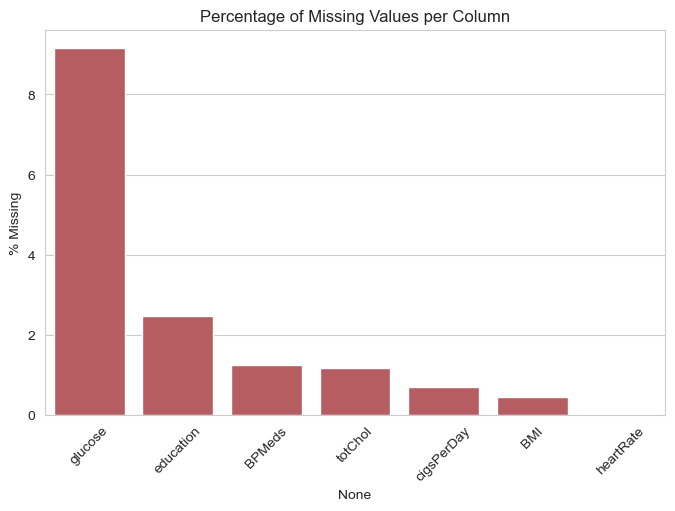

In [34]:
# Visualize missing values
plt.figure()
sns.barplot(x=missing_summary.index, y=missing_summary['Missing %'], color='#C44E52')
plt.xticks(rotation=45)
plt.title('Percentage of Missing Values per Column')
plt.ylabel('% Missing')
plt.show()


In [35]:
# Impute missing values with the MEDIAN of each column
# (Median chosen over mean because clinical features like glucose/cigsPerDay are skewed
#  and median is robust to outliers)
for col in missing_summary.index:
    df[col] = df[col].fillna(df[col].median())

# Confirm no missing values remain
print("Total missing values after imputation:", df.isnull().sum().sum())

Total missing values after imputation: 0


In [36]:
# Check unique values for columns that look categorical
cat_like_cols = ['male', 'education', 'currentSmoker', 'BPMeds', 'prevalentStroke',
                  'prevalentHyp', 'diabetes']
for c in cat_like_cols:
    print(c, '->', sorted(df[c].unique()))

male -> [np.int64(0), np.int64(1)]
education -> [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
currentSmoker -> [np.int64(0), np.int64(1)]
BPMeds -> [np.float64(0.0), np.float64(1.0)]
prevalentStroke -> [np.int64(0), np.int64(1)]
prevalentHyp -> [np.int64(0), np.int64(1)]
diabetes -> [np.int64(0), np.int64(1)]


In [37]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True))
print("Test class balance:\n", y_test.value_counts(normalize=True))

Train shape: (3390, 15)  Test shape: (848, 15)
Train class balance:
 TenYearCHD
0    0.848083
1    0.151917
Name: proportion, dtype: float64
Test class balance:
 TenYearCHD
0    0.847877
1    0.152123
Name: proportion, dtype: float64


In [38]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled = scaler.transform(X_test)          # transform ONLY on test

# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

X_train_scaled.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
1767,-0.872375,0.160422,0.020649,-0.982455,-0.751499,-0.172537,-0.080821,-0.671713,-0.165145,1.109723,0.187178,0.308956,-0.244064,-0.492725,0.060544
2947,-0.872375,1.094437,0.020649,-0.982455,-0.751499,-0.172537,-0.080821,-0.671713,-0.165145,0.973192,-0.017371,0.435256,0.161465,0.173113,0.277917
888,1.146295,0.860933,-0.965272,1.017859,0.084843,-0.172537,-0.080821,1.488731,-0.165145,-0.687939,0.391726,0.014257,0.525713,-1.075334,-0.548101
2026,1.146295,-1.707608,0.020649,1.017859,-0.500596,-0.172537,-0.080821,1.488731,-0.165145,1.041457,-0.971931,0.098457,0.875391,0.339573,-0.156829
2696,-0.872375,-0.773593,-0.965272,1.017859,0.503014,-0.172537,-0.080821,-0.671713,-0.165145,1.792379,0.005357,-0.533042,1.390195,1.588020,-0.156829


In [39]:
print("Before SMOTE:", y_train.value_counts().to_dict())

smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE :", y_train_bal.value_counts().to_dict())

Before SMOTE: {0: 2875, 1: 515}
After SMOTE : {0: 2875, 1: 2875}


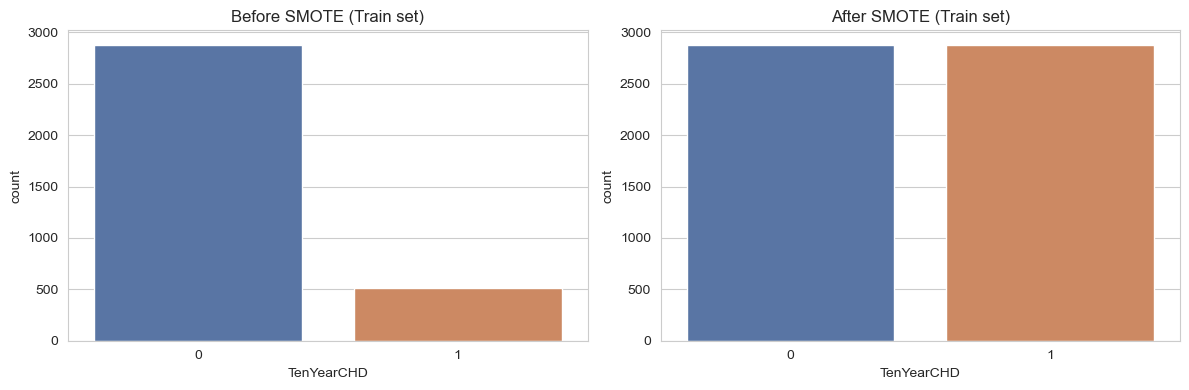

In [40]:
# Visual comparison of class distribution before/after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x=y_train, ax=axes[0], palette=['#4C72B0', '#DD8452'])
axes[0].set_title('Before SMOTE (Train set)')
sns.countplot(x=y_train_bal, ax=axes[1], palette=['#4C72B0', '#DD8452'])
axes[1].set_title('After SMOTE (Train set)')
plt.tight_layout()
plt.show()

In [41]:
# Dictionary of models to train and compare
models = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(random_state=RANDOM_STATE, probability=True),
    'Naive Bayes': GaussianNB(),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE)
}

results = []          # store metric summary for comparison table
trained_models = {}   # keep fitted models for later (confusion matrix, tuning, etc.)

for name, model in models.items():
    # Train on the SMOTE-balanced, scaled training data
    model.fit(X_train_bal, y_train_bal)
    trained_models[name] = model

    # Predict on the untouched test set
    y_pred = model.predict(X_test_scaled)

    # Compute evaluation metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec,
                     'Recall': rec, 'F1-Score': f1})

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.663915,0.248387,0.596899,0.350797
1,SVM,0.696934,0.239837,0.457364,0.314667
2,Gradient Boosting,0.766509,0.280255,0.341085,0.307692
3,KNN,0.642689,0.211921,0.496124,0.296984
4,Decision Tree,0.725236,0.214286,0.302326,0.250804
5,Naive Bayes,0.773585,0.239669,0.224806,0.232000
6,Random Forest,0.800708,0.261905,0.170543,0.206573


===== Logistic Regression =====
              precision    recall  f1-score   support

  No CHD (0)       0.90      0.68      0.77       719
     CHD (1)       0.25      0.60      0.35       129

    accuracy                           0.66       848
   macro avg       0.58      0.64      0.56       848
weighted avg       0.80      0.66      0.71       848

===== Decision Tree =====
              precision    recall  f1-score   support

  No CHD (0)       0.86      0.80      0.83       719
     CHD (1)       0.21      0.30      0.25       129

    accuracy                           0.73       848
   macro avg       0.54      0.55      0.54       848
weighted avg       0.77      0.73      0.74       848

===== Random Forest =====
              precision    recall  f1-score   support

  No CHD (0)       0.86      0.91      0.89       719
     CHD (1)       0.26      0.17      0.21       129

    accuracy                           0.80       848
   macro avg       0.56      0.54      0.55 

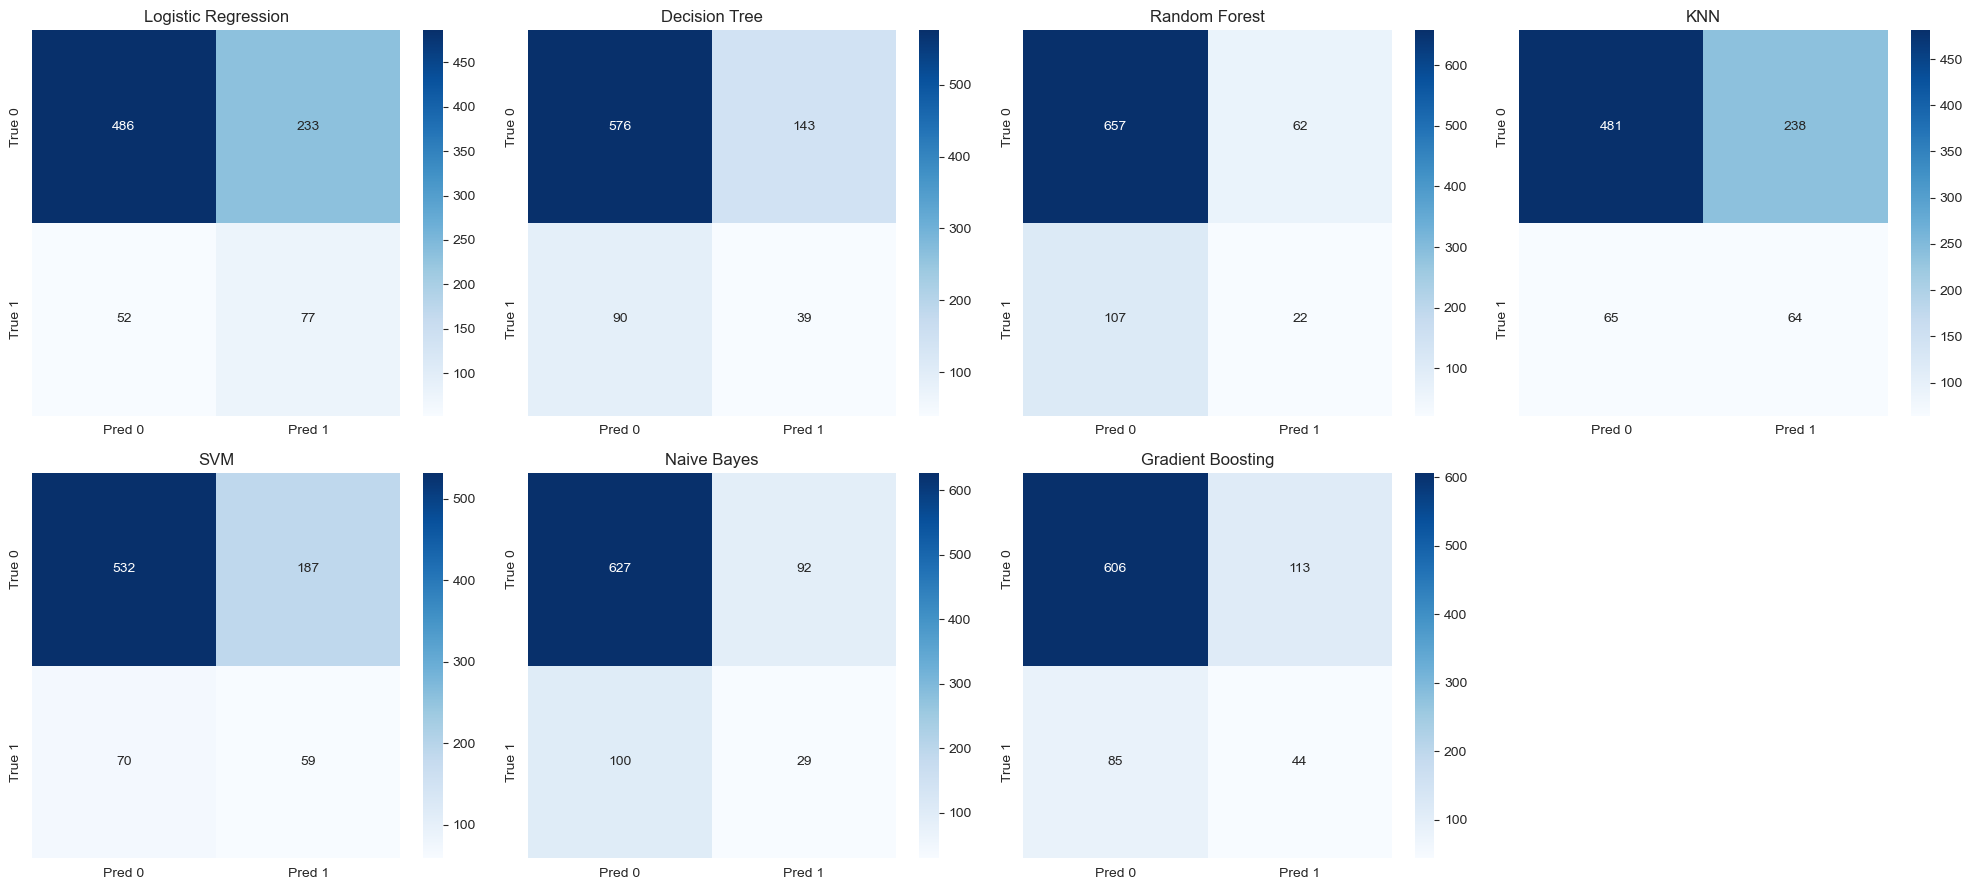

In [42]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test_scaled)

    print(f"===== {name} =====")
    print(classification_report(y_test, y_pred, target_names=['No CHD (0)', 'CHD (1)']))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
    axes[i].set_title(name)

# Hide any unused subplot axes
for j in range(len(trained_models), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

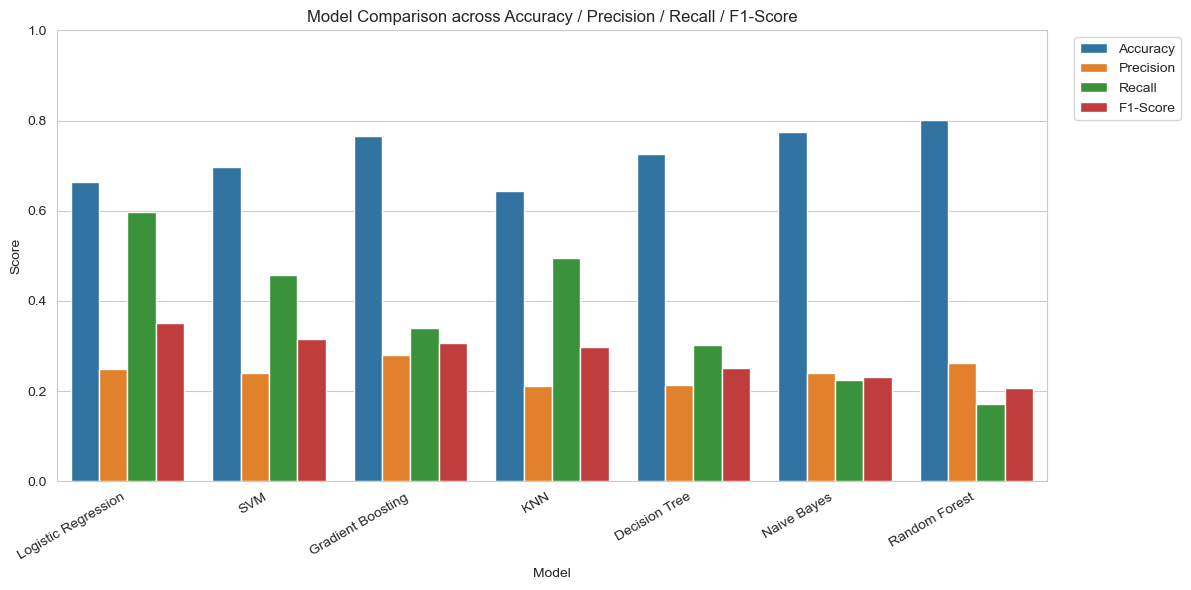

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.663915,0.248387,0.596899,0.350797
1,SVM,0.696934,0.239837,0.457364,0.314667
2,Gradient Boosting,0.766509,0.280255,0.341085,0.307692
3,KNN,0.642689,0.211921,0.496124,0.296984
4,Decision Tree,0.725236,0.214286,0.302326,0.250804
5,Naive Bayes,0.773585,0.239669,0.224806,0.232000
6,Random Forest,0.800708,0.261905,0.170543,0.206573


In [43]:
# Bar chart comparing all models across the 4 key metrics
results_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric')
plt.xticks(rotation=30, ha='right')
plt.title('Model Comparison across Accuracy / Precision / Recall / F1-Score')
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

results_df

In [44]:
# Automatically pick the best model based on F1-Score
best_model_name = results_df.iloc[0]['Model']
print(f"Best performing model (by F1-Score): {best_model_name}")
print(results_df.iloc[0])

Best performing model (by F1-Score): Logistic Regression
Model        Logistic Regression
Accuracy                0.663915
Precision               0.248387
Recall                  0.596899
F1-Score                0.350797
Name: 0, dtype: object


In [45]:
# Parameter grids for each possible best model
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs']
    },
    'Decision Tree': {
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_split': [2, 5, 10],
        'criterion': ['gini', 'entropy']
    },
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5, 10]
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance']
    },
    'SVM': {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear'],
        'gamma': ['scale', 'auto']
    },
    'Naive Bayes': {
        'var_smoothing': [1e-9, 1e-8, 1e-7]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [2, 3, 4]
    }
}

base_model = models[best_model_name]
grid = GridSearchCV(
    estimator=base_model,
    param_grid=param_grids[best_model_name],
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid.fit(X_train_bal, y_train_bal)

print("Best parameters found:", grid.best_params_)
print("Best cross-validated F1-Score:", grid.best_score_)    

Best parameters found: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Best cross-validated F1-Score: 0.6902274948346185


In [46]:
# Evaluate the TUNED model on the test set
best_tuned_model = grid.best_estimator_
y_pred_tuned = best_tuned_model.predict(X_test_scaled)

tuned_acc = accuracy_score(y_test, y_pred_tuned)
tuned_prec = precision_score(y_test, y_pred_tuned)
tuned_rec = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)

print(f"Tuned {best_model_name} — Test Set Performance")
print(f"Accuracy : {tuned_acc:.4f}")
print(f"Precision: {tuned_prec:.4f}")
print(f"Recall   : {tuned_rec:.4f}")
print(f"F1-Score : {tuned_f1:.4f}")
print()
print(classification_report(y_test, y_pred_tuned, target_names=['No CHD (0)', 'CHD (1)']))

Tuned Logistic Regression — Test Set Performance
Accuracy : 0.6580
Precision: 0.2444
Recall   : 0.5969
F1-Score : 0.3468

              precision    recall  f1-score   support

  No CHD (0)       0.90      0.67      0.77       719
     CHD (1)       0.24      0.60      0.35       129

    accuracy                           0.66       848
   macro avg       0.57      0.63      0.56       848
weighted avg       0.80      0.66      0.70       848



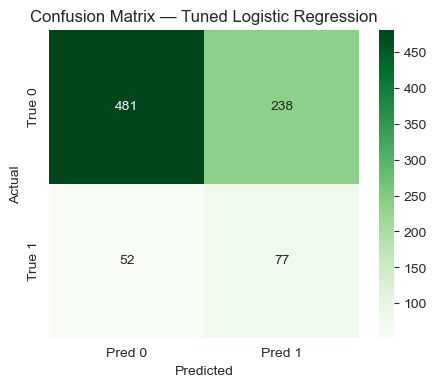

In [47]:
# Confusion matrix of the final tuned model
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
plt.title(f'Confusion Matrix — Tuned {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [48]:
before_after = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    f'{best_model_name} (Before Tuning)': [
        results_df[results_df.Model == best_model_name]['Accuracy'].values[0],
        results_df[results_df.Model == best_model_name]['Precision'].values[0],
        results_df[results_df.Model == best_model_name]['Recall'].values[0],
        results_df[results_df.Model == best_model_name]['F1-Score'].values[0],
    ],
    f'{best_model_name} (After Tuning)': [tuned_acc, tuned_prec, tuned_rec, tuned_f1]
})
before_after


,Metric,Logistic Regression (Before Tuning),Logistic Regression (After Tuning)
0,Accuracy,0.663915,0.658019
1,Precision,0.248387,0.244444
2,Recall,0.596899,0.596899
3,F1-Score,0.350797,0.346847
